# 07 — Integración Componente A ↔ Componente B

El **núcleo del proyecto**: acoplar el detector no supervisado (Componente A, un
VAE) con el predictor de rinde (Componente B). Tres análisis que pide la consigna:

1. **Consistencia cruzada** — ¿el score de anomalía del VAE correlaciona con el
   |residuo| del predictor? Si ambos ven la misma estructura, una campaña "rara"
   para el VAE también le cuesta al regresor (Spearman sobre el test).
2. **Aporte del detector al predictor** (lift) — RMSE del predictor **con vs. sin**
   las features del VAE (latente / score), vía `ev.comparar_latente`.
3. **Cuantificación económica** — rinde **contrafactual** bajo clima normal −
   rinde real, × superficie sembrada → pérdida de la sequía 2022/23, comparable al
   benchmark de la BCR (USD 14.140 M).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


In [2]:
import json
_bpath = 'retuning_cv_honesta.json'
_BEST = json.load(open(_bpath, encoding='utf-8')) if os.path.exists(_bpath) else {}
def best_of(cultivo, name, fallback):
    """best-params re-tuneados de `name` para `cultivo` (o `fallback` si no hay json)."""
    return _BEST.get(cultivo, {}).get(name, {}).get('best_params', fallback)
print('re-tuning disponible:', sorted(_BEST) or 'NO (usando fallbacks)')


re-tuning disponible: ['maiz', 'soja']


In [3]:
import integracion, latente
# Modelo final del predictor (XGBoost re-tuneado) + features del VAE, por cultivo.
# OJO: la 1ra vez entrena el VAE de cada cultivo y lo cachea (tarda unos minutos).
MOD, YP, VF = {}, {}, {}
for c in CULTIVOS:
    d = DSS[c]
    MOD[c] = XGBoostRegressor(**best_of(c, 'xgb', {}), random_state=42).fit(d.X_train, d.y_train)
    YP[c] = MOD[c].predict(d.X_test)
    VF[c] = latente.vae_features(c)
    print(f'{c}: predictor test RMSE={ev.metricas(d.y_test, YP[c])["rmse"]:.0f}')

soja: predictor test RMSE=606
maiz: predictor test RMSE=1721


## 1. Consistencia cruzada (Spearman)

Correlación de Spearman entre el score de anomalía del VAE y el valor absoluto del
residuo del predictor, sobre el test. Positiva y significativa ⇒ **ambos
componentes detectan la misma estructura** (test de robustez metodológica).

soja: Spearman(score VAE, |residuo|) = 0.261 (p=4.1e-16, n=942)
maiz: Spearman(score VAE, |residuo|) = 0.106 (p=2.9e-04, n=1160)


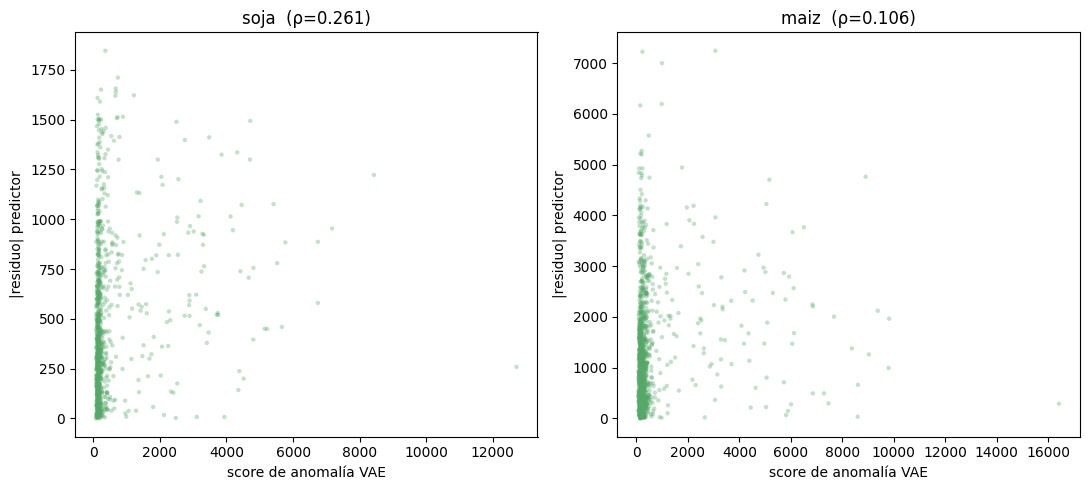

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]
    cc = integracion.consistencia_cruzada(d, YP[c], VF[c])
    print(f'{c}: Spearman(score VAE, |residuo|) = {cc["spearman_rho"]:.3f} '
          f'(p={cc["p_value"]:.1e}, n={cc["n"]})')
    ax.scatter(VF[c]['score_test'], np.abs(d.y_test - YP[c]), s=10, alpha=0.35,
               color=ev.C_XGB, edgecolors='none')
    ax.set_xlabel('score de anomalía VAE'); ax.set_ylabel('|residuo| predictor')
    ax.set_title(f'{c}  (ρ={cc["spearman_rho"]:.3f})')
plt.tight_layout(); plt.show()

## 2. Aporte del detector al predictor (lift)

RMSE del predictor sobre el dataset base vs. tres estrategias que reusan el VAE:
concatenar su **latente**, usar **solo el latente**, y agregar la categórica
**`es_anomalo`**. Si el detector aporta contexto climático comprimido, debería
bajar el RMSE (sobre todo en campañas extremas). Se reporta por cultivo.

In [5]:
for c in CULTIVOS:
    print(f'=== lift del latente — {c} ===')
    tl = ev.comparar_latente(XGBoostRegressor, best_of(c, 'xgb', {}), c,
                             fixed={'random_state': 42},
                             vae_kwargs=dict(score_seeds=(42, 43, 44)))
    display(tl)

=== lift del latente — soja ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,466.482,594.412,0.398,25.617,21.888
1,dataset unificado,74,475.215,611.672,0.363,26.662,22.234
2,+ es_anomalo,75,495.461,624.528,0.336,25.953,23.167
3,solo latente,16,722.146,873.951,-0.301,31.811,33.101


=== lift del latente — maiz ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,"1,199.483","1,593.809",0.369,30.706,25.509
1,+ es_anomalo,75,"1,239.187","1,612.150",0.354,31.031,26.581
2,dataset unificado,74,"1,300.069","1,715.214",0.269,33.901,26.998
3,solo latente,16,"2,190.042","2,641.869",-0.734,38.060,46.435


## 3. Cuantificación económica de la sequía 2022/23

Rinde **contrafactual** (qué habría rendido cada depto con clima normal, poniendo
las features climáticas en su media de train) − rinde real, ponderado por
superficie sembrada. Agregamos la campaña 2022/23 por cultivo y miramos los deptos
más golpeados.

In [6]:
RES = {}
for c in CULTIVOS:
    d = DSS[c]
    y_cf = integracion.contrafactual_normal(MOD[c], d)
    RES[c] = integracion.resumen_2223(d, y_cf)
    print(f'{c} 2022/23 ({RES[c]["n_filas"]} deptos): pérdida total '
          f'{RES[c]["perdida_total_tn"]:,.0f} tn ({RES[c]["perdida_media_kgha"]:.0f} kg/ha prom.)')

soja 2022/23 (236 deptos): pérdida total 14,667,893 tn (848 kg/ha prom.)
maiz 2022/23 (289 deptos): pérdida total 19,963,394 tn (1894 kg/ha prom.)


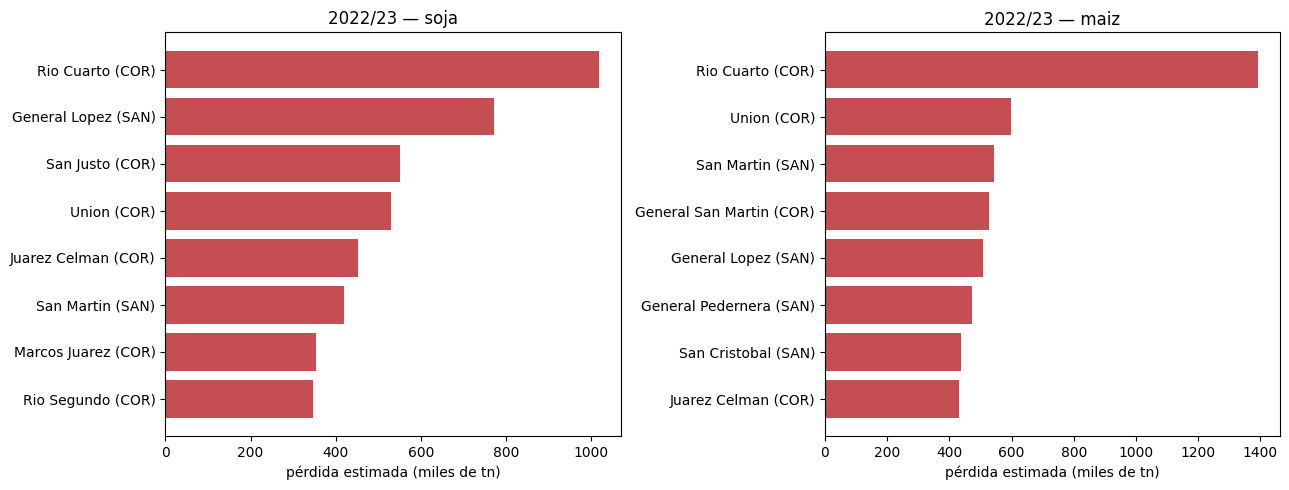

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, c in zip(axes, CULTIVOS):
    top = RES[c]['top_deptos'].head(8).iloc[::-1]
    ax.barh(top['departamento'] + ' (' + top['provincia'].str[:3] + ')',
            top['perdida_tn'] / 1e3, color='#C44E52')
    ax.set_xlabel('pérdida estimada (miles de tn)'); ax.set_title(f'2022/23 — {c}')
plt.tight_layout(); plt.show()

## Conclusión

- **Consistencia cruzada:** la correlación positiva y significativa entre el score
  del VAE y el residuo del predictor indica que ambos componentes captan la misma
  señal de anomalía — el sistema es coherente de punta a punta.
- **Lift del latente:** en línea con el techo estructural del Componente A, el
  latente del VAE aporta poco a la regresión (resume el clima *normalizado por
  depto*, tira la señal espacial/tendencia que domina el rinde). El aporte real del
  acople es **conceptual y económico**, no un salto de RMSE.
- **Cuantificación:** el contrafactual aísla la campaña 2022/23 como pérdida masiva
  concentrada en el sur de Córdoba y Santa Fe, consistente con la sequía histórica y
  el orden de magnitud del benchmark BCR.